In [3]:
import os
DATA = "/Users/enkh-oyun0218/Documents/Portfolio Projects/aml-graph/data"
print(os.listdir(DATA))

['graph_edges.csv', 'DOWNLOAD_DATA.md', 'HI-Small_Patterns.txt', 'HI-Small_Trans.csv', 'graph_nodes.csv']


In [4]:
import pandas as pd

cols = ["Timestamp","FromBank","FromAccount","ToBank","ToAccount",
        "AmountReceived","ReceivingCurrency","AmountPaid","PaymentCurrency",
        "PaymentFormat","IsLaundering"]

df = pd.read_csv(f"{DATA}/HI-Small_Trans.csv", header=0, names=cols)
print(df.shape)
df.head()

(5078345, 11)


,Timestamp,FromBank,FromAccount,ToBank,ToAccount,AmountReceived,ReceivingCurrency,AmountPaid,PaymentCurrency,PaymentFormat,IsLaundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [5]:
# 1. what is the percentage of laundering out of the whole?
print(df["IsLaundering"].value_counts())
print("laundering rate:", round(df["IsLaundering"].mean()*100, 4), "%")

# 2. how big is the graph? (accounts = nodes)
accounts = pd.concat([df["FromAccount"], df["ToAccount"]]).nunique()
print("unique accounts:", accounts)

# 3. payment types and currencies
print(df["PaymentFormat"].value_counts())
print("currencies:", df["ReceivingCurrency"].nunique())

# 4. self-transactions (same account on both ends)
print("self-loops:", (df["FromAccount"] == df["ToAccount"]).sum())

IsLaundering
0    5073168
1       5177
Name: count, dtype: int64
laundering rate: 0.1019 %
unique accounts: 515080
PaymentFormat
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64
currencies: 15
self-loops: 591212


In [6]:
# convert the timestamp text into real datetime values
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
print("from", df["Timestamp"].min(), "to", df["Timestamp"].max())

# laundering rate within each payment format, highest first
rate_by_format = df.groupby("PaymentFormat")["IsLaundering"].mean().sort_values(ascending=False)
print((rate_by_format * 100).round(3))

from 2022-09-01 00:00:00 to 2022-09-18 16:18:00
PaymentFormat
ACH             0.746
Bitcoin         0.038
Cash            0.022
Cheque          0.017
Credit Card     0.016
Reinvestment    0.000
Wire            0.000
Name: IsLaundering, dtype: float64


In [7]:
from collections import Counter

typologies = []
with open(f"{DATA}/HI-Small_Patterns.txt") as f:
    for line in f:
        if line.startswith("BEGIN LAUNDERING ATTEMPT"):
            typ = line.split("-", 1)[1].split(":")[0].strip()
            typologies.append(typ)

print("total laundering rings:", len(typologies))
print(Counter(typologies))

total laundering rings: 370
Counter({'CYCLE': 54, 'GATHER-SCATTER': 51, 'BIPARTITE': 49, 'FAN-OUT': 48, 'SCATTER-GATHER': 44, 'STACK': 43, 'RANDOM': 41, 'FAN-IN': 40})


In [8]:
import networkx as nx

# drop self-loops (money to the same account; not a transfer)
edges = df[df["FromAccount"] != df["ToAccount"]].copy()
print("transactions after dropping self-loops:", len(edges))

# collapse repeated payments between the same pair into one edge
edge_df = (edges.groupby(["FromAccount", "ToAccount"])
                 .agg(n_txns=("AmountPaid", "size"),
                      total_amount=("AmountPaid", "sum"),
                      any_laundering=("IsLaundering", "max"))
                 .reset_index())
print("unique directed pairs (edges):", len(edge_df))

transactions after dropping self-loops: 4487133
unique directed pairs (edges): 647939


In [9]:
G = nx.from_pandas_edgelist(
    edge_df,
    source="FromAccount",
    target="ToAccount",
    edge_attr=["n_txns", "total_amount", "any_laundering"],
    create_using=nx.DiGraph()
)
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())

nodes: 422726
edges: 647939


In [10]:
# how many directed pairs involved any laundering?
print("laundering edges:", int(edge_df["any_laundering"].sum()))

# peek at a few laundering edges
edge_df[edge_df["any_laundering"] == 1].head()

laundering edges: 4929


,FromAccount,ToAccount,n_txns,total_amount,any_laundering
4,100428660,800057620,30,25576.50,1
140,100428660,800265A20,21,2181.13,1
358,100428660,8005C1C10,30,16366925.80,1
382,100428660,8005F0950,21,5215.28,1
386,100428660,8005FF6D0,2,32558.18,1


In [11]:
# which accounts were ever involved in laundering (as sender or receiver)?
laund = df[df["IsLaundering"] == 1]
laundering_accounts = set(laund["FromAccount"]) | set(laund["ToAccount"])

# node list: every account + a flag
all_accounts = pd.concat([edges["FromAccount"], edges["ToAccount"]]).unique()
nodes_df = pd.DataFrame({"account": all_accounts})
nodes_df["laundering_involved"] = nodes_df["account"].isin(laundering_accounts).astype(int)

# save both files for Neo4j to import
edge_df.to_csv(f"{DATA}/graph_edges.csv", index=False)
nodes_df.to_csv(f"{DATA}/graph_nodes.csv", index=False)
print("saved graph_nodes.csv:", nodes_df.shape, "| graph_edges.csv:", edge_df.shape)

saved graph_nodes.csv: (422726, 2) | graph_edges.csv: (647939, 5)


In [12]:
# confirm the graph is still loaded from Part 2
print("graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

import networkx as nx

# per-account structural features (no labels used -> leakage-free)
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

print("computing PageRank (about a minute)...")
pr = nx.pagerank(G)
print("done")

graph nodes: 422726 edges: 647939
computing PageRank (about a minute)...
done


In [13]:
# top 10 accounts by PageRank
top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
for acct, score in top:
    print(acct, round(score, 6))

print("\nsum of all scores:", round(sum(pr.values()), 4))
print("average score:", sum(pr.values()) / len(pr))
print("max:", max(pr.values()), " min:", min(pr.values()))

100428660 0.000409
1004286A8 0.000247
80E874DB0 0.000129
80640B300 0.000126
80640FE10 0.000126
8026F6870 0.000122
811588F30 0.000122
802508900 0.000122
805699E80 0.000122
80F47A310 0.000122

sum of all scores: 1.0
average score: 2.3655985200806917e-06
max: 0.00040858621159325323  min: 1.1690594368140133e-06


In [15]:
import pandas as pd

cols = ["Timestamp", "FromAccount", "ToAccount", "AmountPaid",
        "PaymentFormat", "ReceivingCurrency", "IsLaundering"]
model_df = edges[cols].copy()

model_df["from_in"]  = model_df["FromAccount"].map(in_deg)
model_df["from_out"] = model_df["FromAccount"].map(out_deg)
model_df["from_pr"]  = model_df["FromAccount"].map(pr)
model_df["to_in"]    = model_df["ToAccount"].map(in_deg)
model_df["to_out"]   = model_df["ToAccount"].map(out_deg)
model_df["to_pr"]    = model_df["ToAccount"].map(pr)

print(model_df.shape)
model_df.head()

(4487133, 13)


,Timestamp,FromAccount,ToAccount,AmountPaid,PaymentFormat,ReceivingCurrency,IsLaundering,from_in,from_out,from_pr,to_in,to_out,to_pr
1,2022-09-01 00:20:00,8000F4580,8000F5340,0.01,Cheque,US Dollar,0,0,2,0.000001,14,2,0.000004
8,2022-09-01 00:26:00,8000EC280,8017BF800,7.66,Credit Card,US Dollar,0,1,10,0.000002,6,3,0.000002
9,2022-09-01 00:21:00,8000EDEC0,80AEF5310,383.71,Credit Card,US Dollar,0,0,11,0.000001,8,0,0.000002
10,2022-09-01 00:04:00,8000F4510,8011305D0,9.82,Credit Card,US Dollar,0,0,11,0.000001,3,2,0.000002
12,2022-09-01 00:08:00,8000F4FE0,812ED62E0,4.01,Credit Card,US Dollar,0,1,13,0.000002,4,1,0.000004


In [18]:
daily = model_df.groupby(model_df["Timestamp"].dt.date).agg(
    total=("IsLaundering", "size"),
    laundering=("IsLaundering", "sum"))
daily["rate_%"] = (daily["laundering"] / daily["total"] * 100).round(3)
print(daily)

             total  laundering   rate_%
Timestamp                              
2022-09-01  607511         321    0.053
2022-09-02  738969         408    0.055
2022-09-03  203050         390    0.192
2022-09-04  203066         405    0.199
2022-09-05  472251         470    0.100
2022-09-06  471688         530    0.112
2022-09-07  472361         497    0.105
2022-09-08  472365         539    0.114
2022-09-09  641223         513    0.080
2022-09-10  203934         441    0.216
2022-09-11     265         231   87.170
2022-09-12     181         170   93.923
2022-09-13     115         106   92.174
2022-09-14      78          70   89.744
2022-09-15      28          27   96.429
2022-09-16      26          26  100.000
2022-09-17      14          14  100.000
2022-09-18       8           8  100.000


In [19]:
# keep only the realistic, dense window; drop the degenerate tail (after Sept 10)
dense = model_enc[model_enc["Timestamp"] < pd.Timestamp("2022-09-11")]

# temporal split inside that window
split_time = pd.Timestamp("2022-09-09")
train = dense[dense["Timestamp"] <  split_time]   # Sept 1-8
test  = dense[dense["Timestamp"] >= split_time]   # Sept 9-10

print("train:", train.shape, "| laundering:", int(train["IsLaundering"].sum()),
      "| rate:", round(train["IsLaundering"].mean()*100, 3), "%")
print("test :", test.shape,  "| laundering:", int(test["IsLaundering"].sum()),
      "| rate:", round(test["IsLaundering"].mean()*100, 3), "%")

train: (3641261, 32) | laundering: 3560 | rate: 0.098 %
test : (845157, 32) | laundering: 954 | rate: 0.113 %


In [20]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, classification_report

# feature groups
graph_cols   = ["from_in","from_out","from_pr","to_in","to_out","to_pr"]
drop_cols    = ["Timestamp","FromAccount","ToAccount","IsLaundering"]
feature_cols = [c for c in train.columns if c not in drop_cols]   # tabular + graph
tabular_cols = [c for c in feature_cols if c not in graph_cols]   # tabular only

y_train = train["IsLaundering"]
y_test  = test["IsLaundering"]

# imbalance weight: how many clean per laundering (~1000)
spw = (y_train == 0).sum() / (y_train == 1).sum()

def run(cols, name):
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      scale_pos_weight=spw, eval_metric="aucpr",
                      tree_method="hist", n_jobs=-1)
    m.fit(train[cols], y_train)
    proba = m.predict_proba(test[cols])[:, 1]
    pred  = (proba >= 0.5).astype(int)
    print(f"=== {name} ({len(cols)} features) ===")
    print("PR-AUC:", round(average_precision_score(y_test, proba), 3))
    print(classification_report(y_test, pred, digits=3))
    return m

m_base  = run(tabular_cols, "BASELINE (tabular only)")
m_graph = run(feature_cols, "+ GRAPH features")

=== BASELINE (tabular only) (22 features) ===
PR-AUC: 0.058
              precision    recall  f1-score   support

           0      1.000     0.917     0.957    844203
           1      0.011     0.841     0.022       954

    accuracy                          0.917    845157
   macro avg      0.506     0.879     0.490    845157
weighted avg      0.999     0.917     0.956    845157

=== + GRAPH features (28 features) ===
PR-AUC: 0.281
              precision    recall  f1-score   support

           0      1.000     0.928     0.962    844203
           1      0.013     0.843     0.026       954

    accuracy                          0.928    845157
   macro avg      0.506     0.885     0.494    845157
weighted avg      0.999     0.928     0.961    845157



In [22]:
import pandas as pd
imp = pd.Series(m_graph.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(imp.head(12))

PaymentFormat_ACH                 0.645319
from_out                          0.087963
PaymentFormat_Bitcoin             0.046394
from_pr                           0.019825
AmountPaid                        0.013759
ReceivingCurrency_US Dollar       0.013178
ReceivingCurrency_Rupee           0.011210
PaymentFormat_Cheque              0.010235
ReceivingCurrency_Yen             0.009979
ReceivingCurrency_Mexican Peso    0.009948
ReceivingCurrency_Ruble           0.009919
to_pr                             0.009762
dtype: float32


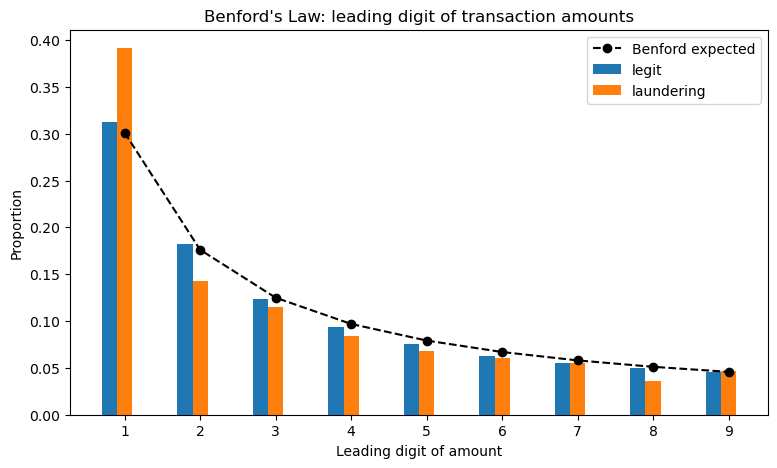

In [25]:
import numpy as np
import matplotlib.pyplot as plt

FIG = "/Users/enkh-oyun0218/Documents/Portfolio Projects/aml-graph/figures"

def leading_digit(arr):
    arr = np.abs(arr)
    arr = arr[arr > 0]
    return (arr / 10**np.floor(np.log10(arr))).astype(int)

amounts = model_df["AmountPaid"].values
labels  = model_df["IsLaundering"].values

legit_ld = leading_digit(amounts[labels == 0])
laund_ld = leading_digit(amounts[labels == 1])

digits  = np.arange(1, 10)
benford = np.log10(1 + 1/digits)   # the expected Benford proportions

def dist(ld):
    return np.array([(ld == d).mean() for d in digits])

plt.figure(figsize=(9, 5))
plt.bar(digits - 0.2, dist(legit_ld), width=0.2, label="legit")
plt.bar(digits + 0.0, dist(laund_ld), width=0.2, label="laundering")
plt.plot(digits, benford, "k--o", label="Benford expected")
plt.xlabel("Leading digit of amount"); plt.ylabel("Proportion")
plt.title("Benford's Law: leading digit of transaction amounts")
plt.xticks(digits); plt.legend()
plt.savefig(f"{FIG}/benford.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
self_loops = df[df["FromAccount"] == df["ToAccount"]]
print("total self-loops:", len(self_loops))
print("\npayment formats among self-loops:")
print(self_loops["PaymentFormat"].value_counts())
print("\nlaundering among self-loops:", int(self_loops["IsLaundering"].sum()))

total self-loops: 591212

payment formats among self-loops:
PaymentFormat
Reinvestment    481056
ACH              71347
Bitcoin          26317
Cheque            6066
Credit Card       4176
Cash              1455
Wire               795
Name: count, dtype: int64

laundering among self-loops: 11
